In [2]:
import os
os.chdir('../../../../..')

In [4]:
import numpy as np
import hdbscan
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
import gc
import numpy as np
from tqdm import tqdm
import polars as pl
from dscribe.descriptors import SOAP
from rdkit import Chem
import numpy as np
import polars as pl
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolDescriptors
import numpy as np
import numpy as np, gc
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import r2_score, mean_absolute_error
import polars as pl
from ase import Atoms
from dscribe.descriptors import SOAP
from rdkit import Chem
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, ParameterGrid
from dscribe.kernels import REMatchKernel
from sklearn.kernel_ridge import KernelRidge
from sklearn.preprocessing import StandardScaler
import gc
import multiprocessing
from concurrent.futures import ThreadPoolExecutor
import polars as pl
from tqdm import tqdm

from scripts.qm9.chemprop import CheMeleonFingerprint




from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
from kmedoids import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from umap import UMAP

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster, evaluate_hdbscan_grid, get_isomers

projection_method = "MDS"

In [5]:
qm9 = QM9Dataset(limit=80_000, descriptors=["soap"])
df = qm9.load()

2026-06-15 10:56:39.308 | INFO     | src.datasets:_load_full_qm9_df:935 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-06-15 10:56:39.827 | INFO     | src.datasets:_sample_qm9_df:1119 - QM9 sampling complete: strategy=stratified, requested_limit=80000, returned_rows=80000, sampling on columns=['num_atoms', 'gap'].
2026-06-15 10:56:39.835 | INFO     | src.datasets:_add_requested_descriptors:293 - Applying requested QM9 descriptors to sampled dataframe (rows=80000).
2026-06-15 10:56:39.920 | INFO     | src.features:compute_soap_outputs:395 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-06-15 11:02:36.170 | SUCCESS  | src.datasets:add_soap:1307 - Added SOAP embeddings and matrices.
2026-06-15 11:02:36.258 | INFO     | src.datasets:_add_requested_descriptors:304 - Added descriptor column(s): ['soap_embedding', 'soap_matrix']
2026-06-15 11:02:36.453 | INFO     | src.datasets:_load_with_descriptor_filter:975 - QM9 descriptor null-filtering 

In [6]:
def remove_explicit_hydrogens(smiles: str) -> str:
    if smiles is None:
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mol_no_h = Chem.RemoveHs(mol)
    return Chem.MolToSmiles(mol_no_h)
df = df.with_columns(
    pl.col("smiles")
    .map_elements(remove_explicit_hydrogens, return_dtype=pl.String)
    .alias("smiles") 
)

# Hypothesis 1
- Goal is to tell a story of how SOAP improves on some of the flaws that morgan fingerprint has.



In [7]:
def generate_soap_features(
    df: pl.DataFrame,
    r_cut: float = 4.5,
    n_max: int = 8,
    l_max: int = 6,
    sigma: float = 0.5,
) -> pl.DataFrame:
    """Generates species-resolved, averaged SOAP molecular embeddings from a Polars

    DataFrame containing 'atomic_numbers' and 'coordinates'.
    """
    # 1. Define the complete chemical space of your dataset (QM9 baseline)
    all_species = ["H", "C", "N", "O", "F"]

    # 2. Initialize the tunable DScribe SOAP engine
    soap_engine = SOAP(
        species=all_species,
        r_cut=r_cut,
        n_max=n_max,
        l_max=l_max,
        sigma=sigma,
        sparse=False,
    )

    def process_row(atomic_numbers, coordinates):
        """Worker function that processes a single molecule's geometry row."""
        if atomic_numbers is None or coordinates is None:
            return None

        symbols = [Chem.Atom(int(z)).GetSymbol() for z in atomic_numbers]
        positions = np.array(coordinates)

        try:
            system = Atoms(symbols=symbols, positions=positions)
        except Exception:
            return None

        try:
            atomic_soap = soap_engine.create(system)
        except Exception:
            return None

        global_molecular_average = np.mean(atomic_soap, axis=0)
        return global_molecular_average.tolist()

    print(
        f"Computing SOAP (rcut={r_cut}, nmax={n_max}, lmax={l_max}, elements={len(all_species)})..."
    )

    # 3. Execute row-by-row using Polars struct mapping
    return df.with_columns(
        pl.struct(["atomic_numbers", "coordinates"])
        .map_elements(
            lambda row: process_row(row["atomic_numbers"], row["coordinates"]),
            return_dtype=pl.List(pl.Float64),
        )
        .alias("soap_embedding")
    )

def generate_morgan_features(
    df: pl.DataFrame,
    radius: int = 2,
    n_bits: int = 2048,
    use_counts: bool = True,
) -> pl.DataFrame:
    """Generates tunable Morgan Fingerprint arrays from a SMILES column."""

    def process_smiles(smiles):
        if smiles is None:
            return None

        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None

        mol = Chem.RemoveHs(mol)

        if use_counts:
            # FIXED: Use GetMorganFingerprint for count/sparse representations
            fp = AllChem.GetMorganFingerprint(smiles, radius=radius)
            arr = np.zeros((n_bits,), dtype=np.int32)
            # Fold arbitrary sparse fragment keys into the fixed bit bucket array
            for idx, count in fp.GetNonzeroElements().items():
                arr[idx % n_bits] += count
        else:
            # Traditional binary bit array layout
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
            arr = np.zeros((1,), dtype=np.int32)
            Chem.DataStructs.ConvertToNumpyArray(fp, arr)

        return arr.tolist()

    print(
        f"Computing Morgan Fingerprints (radius={radius}, n_bits={n_bits}, counts={use_counts})..."
    )

    return df.with_columns(
        pl.col("smiles")
        .map_elements(process_smiles, return_dtype=pl.List(pl.Int32))
        .alias("morgan_fingerprint")
    )


In [8]:
def evaluate_representation_safely(df_processed, feature_col, name,
                                   target="gap", cv_folds=5, random_state=42):
    """Best-of-kernel KRR. Hyperparameters chosen by CV on the TRAINING split
    only; the test set is evaluated exactly once. Every representation sees the
    identical kernel menu, so the comparison is fair."""
    y = df_processed[target].to_numpy()
    X = np.vstack(df_processed[feature_col].to_list())

    idx = np.arange(len(y))
    tr, te = train_test_split(idx, test_size=0.2, random_state=random_state)
    X_tr, X_te, y_tr, y_te = X[tr], X[te], y[tr], y[te]

    alphas = np.logspace(-5, 1, 7).tolist()
    gammas = np.logspace(-6, 0, 7).tolist()
    pipe = Pipeline([("scale", StandardScaler()), ("krr", KernelRidge())])

    # Same menu for ChemProp and SOAP. cosine runs on L2-normalised features
    # (its natural domain), the others on standardised features.
    param_grid = [
        {"scale": [StandardScaler()], "krr__kernel": ["linear"],    "krr__alpha": alphas},
        {"scale": [StandardScaler()], "krr__kernel": ["rbf"],       "krr__alpha": alphas, "krr__gamma": gammas},
        {"scale": [StandardScaler()], "krr__kernel": ["laplacian"], "krr__alpha": alphas, "krr__gamma": gammas},
        {"scale": [Normalizer()],     "krr__kernel": ["cosine"],    "krr__alpha": alphas},
    ]

    search = GridSearchCV(pipe, param_grid, scoring="r2", cv=cv_folds, n_jobs=-1)
    search.fit(X_tr, y_tr)                     # CV stays inside the training split

    best = search.best_estimator_
    preds = best.predict(X_te)                 # test set used once
    test_r2  = r2_score(y_te, preds)
    test_mae = mean_absolute_error(y_te, preds)
    kernel = search.best_params_["krr__kernel"]

    print(f"[{name}] kernel={kernel} | CV R2={search.best_score_:.4f} "
          f"| test R2={test_r2:.4f} | test MAE={test_mae:.4f}")

    del X, X_tr, X_te, y_tr, y_te, search, best
    gc.collect()
    return test_mae, test_r2, kernel

In [9]:
n_planar    = df.filter(pl.col("pbf_score") < 0.1).height
n_nonplanar = df.filter(pl.col("pbf_score") >= 0.1).height
n_match = min(n_planar, n_nonplanar)
print(f"planar={n_planar}, non-planar={n_nonplanar}, matched cohort={n_match}")

evaluation_cohorts = [
    ("PLANAR DATASET",     df.filter(pl.col("pbf_score") < 0.1).sample(n_match, seed=42)),
    ("NON-PLANAR DATASET", df.filter(pl.col("pbf_score") >= 0.1).sample(n_match, seed=42)),
]

# Shared SOAP parameter sweeps
soap_configs = [
    {"r_cut": 4.5, "n_max": 8, "l_max": 6, "sigma": 0.5},
    {"r_cut": 6.0, "n_max": 8, "l_max": 6, "sigma": 0.4},
]

# =====================================================================
# 3. COMPREHENSIVE MULTI-MODAL EVALUATION LOOP
# =====================================================================
for cohort_name, df_cohort in evaluation_cohorts:
    print("\n" + "="*80)
    print(f" BEGINNING REPRESENTATION BENCHMARK: {cohort_name}")
    print("="*80)
    
    # -----------------------------------------------------------------
    # A. CHEMPROP REPRESENTATION RUN
    # -----------------------------------------------------------------
    print(f"\n--- [{cohort_name}] Processing ChemProp Embedding Space ---")
    chemeleon_fingerprint = CheMeleonFingerprint()
    smiles_col = "canonical_smiles"
    
    # Generate continuous graph features mapped to this cohort slice
    chemprop_embeddings_list = chemeleon_fingerprint(df_cohort[smiles_col].to_list())
    
    df_chemprop = df_cohort.with_columns(
        pl.Series("chemprop_embedding", chemprop_embeddings_list)
    ).filter(pl.col("chemprop_embedding").is_not_null())
    
    evaluate_representation_safely(
        df_chemprop, 
        "chemprop_embedding", 
        f"ChemProp ({cohort_name})"
    )
    
    # Active cleanup pass to prevent footprint leakage into the SOAP loops
    del chemprop_embeddings_list, df_chemprop, chemeleon_fingerprint
    gc.collect()
    
    # -----------------------------------------------------------------
    # B. SOAP GEOMETRIC REPRESENTATION SWEEP
    # -----------------------------------------------------------------
    print(f"\n--- [{cohort_name}] Tuning SOAP 3D Geometric Space ---")
    for i, conf in enumerate(soap_configs):
        print(f"\n[SOAP CONFIG {i}] Generating structural distributions...")
        
        df_soap_temp = generate_soap_features(df_cohort, **conf)
        df_soap_temp = df_soap_temp.filter(pl.col("soap_embedding").is_not_null())
        
        evaluate_representation_safely(
            df_soap_temp,
            "soap_embedding",
            f"SOAP_Config_{i} ({cohort_name} | Cut={conf['r_cut']})",
        )
        
        del df_soap_temp
        gc.collect()
        
    print(f"\n[!] Finished evaluation for cohort: {cohort_name}")
    print("-" * 80)

print("\n[SUCCESS] Cross-modal structural comparisons executed across both geometric environments.")

planar=2932, non-planar=77068, matched cohort=2932


2026-06-15 11:02:56.321 | INFO     | scripts.qm9.chemprop:__init__:28 - Initializing CheMeleonFingerprint generator...
2026-06-15 11:02:56.393 | INFO     | scripts.qm9.chemprop:__init__:48 - Found existing CheMeleon weights at /Users/karlfindhansen/.chemprop/chemeleon_mp.pt



 BEGINNING REPRESENTATION BENCHMARK: PLANAR DATASET

--- [PLANAR DATASET] Processing ChemProp Embedding Space ---


2026-06-15 11:02:56.693 | SUCCESS  | scripts.qm9.chemprop:__init__:54 - Successfully loaded CheMeleon message passing weights.
2026-06-15 11:02:56.816 | INFO     | scripts.qm9.chemprop:__call__:75 - Generating CheMeleon fingerprints for 2932 molecules...
2026-06-15 11:03:00.747 | SUCCESS  | scripts.qm9.chemprop:__call__:100 - Successfully generated 2932 fingerprints of dimension 2048.
python(3262) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3263) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3264) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3265) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3266) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3267) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(3268) MallocStackLoggin

[ChemProp (PLANAR DATASET)] kernel=laplacian | CV R2=0.8095 | test R2=0.8320 | test MAE=0.2330

--- [PLANAR DATASET] Tuning SOAP 3D Geometric Space ---

[SOAP CONFIG 0] Generating structural distributions...
Computing SOAP (rcut=4.5, nmax=8, lmax=6, elements=5)...
[SOAP_Config_0 (PLANAR DATASET | Cut=4.5)] kernel=rbf | CV R2=0.9042 | test R2=0.9228 | test MAE=0.1468

[SOAP CONFIG 1] Generating structural distributions...
Computing SOAP (rcut=6.0, nmax=8, lmax=6, elements=5)...


2026-06-15 11:33:37.070 | INFO     | scripts.qm9.chemprop:__init__:28 - Initializing CheMeleonFingerprint generator...
2026-06-15 11:33:37.073 | INFO     | scripts.qm9.chemprop:__init__:48 - Found existing CheMeleon weights at /Users/karlfindhansen/.chemprop/chemeleon_mp.pt


[SOAP_Config_1 (PLANAR DATASET | Cut=6.0)] kernel=rbf | CV R2=0.8678 | test R2=0.9338 | test MAE=0.1343

[!] Finished evaluation for cohort: PLANAR DATASET
--------------------------------------------------------------------------------

 BEGINNING REPRESENTATION BENCHMARK: NON-PLANAR DATASET

--- [NON-PLANAR DATASET] Processing ChemProp Embedding Space ---


2026-06-15 11:33:37.135 | SUCCESS  | scripts.qm9.chemprop:__init__:54 - Successfully loaded CheMeleon message passing weights.
2026-06-15 11:33:37.146 | INFO     | scripts.qm9.chemprop:__call__:75 - Generating CheMeleon fingerprints for 2932 molecules...
2026-06-15 11:33:42.988 | SUCCESS  | scripts.qm9.chemprop:__call__:100 - Successfully generated 2932 fingerprints of dimension 2048.


[ChemProp (NON-PLANAR DATASET)] kernel=laplacian | CV R2=0.8310 | test R2=0.8764 | test MAE=0.3311

--- [NON-PLANAR DATASET] Tuning SOAP 3D Geometric Space ---

[SOAP CONFIG 0] Generating structural distributions...
Computing SOAP (rcut=4.5, nmax=8, lmax=6, elements=5)...
[SOAP_Config_0 (NON-PLANAR DATASET | Cut=4.5)] kernel=rbf | CV R2=0.8237 | test R2=0.8653 | test MAE=0.3486

[SOAP CONFIG 1] Generating structural distributions...
Computing SOAP (rcut=6.0, nmax=8, lmax=6, elements=5)...


KeyboardInterrupt: 

# Hypothesis 1.1

[-] Initializing base butane molecular graph...
[-] Embedding and optimizing 3D conformational rotamers...


2026-05-31 13:47:38.065 | INFO     | scripts.qm9.chemprop:__init__:28 - Initializing CheMeleonFingerprint generator...
2026-05-31 13:47:38.068 | INFO     | scripts.qm9.chemprop:__init__:48 - Found existing CheMeleon weights at /Users/karlfindhansen/.chemprop/chemeleon_mp.pt
2026-05-31 13:47:38.139 | SUCCESS  | scripts.qm9.chemprop:__init__:54 - Successfully loaded CheMeleon message passing weights.
2026-05-31 13:47:38.150 | INFO     | scripts.qm9.chemprop:__call__:75 - Generating CheMeleon fingerprints for 30 molecules...
2026-05-31 13:47:38.203 | SUCCESS  | scripts.qm9.chemprop:__call__:100 - Successfully generated 30 fingerprints of dimension 2048.



[-] Extracting 2D Topological Morgan Fingerprints (Stereo-Aware)...
    -> Are all 2D Morgan bitvectors completely identical?: True
[-] Extracting 2D Learned ChemProp Embeddings...
[-] Extracting 3D Geometric SOAP Descriptors...

[-] Generating updated Multi-Modal Performance Canvas...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


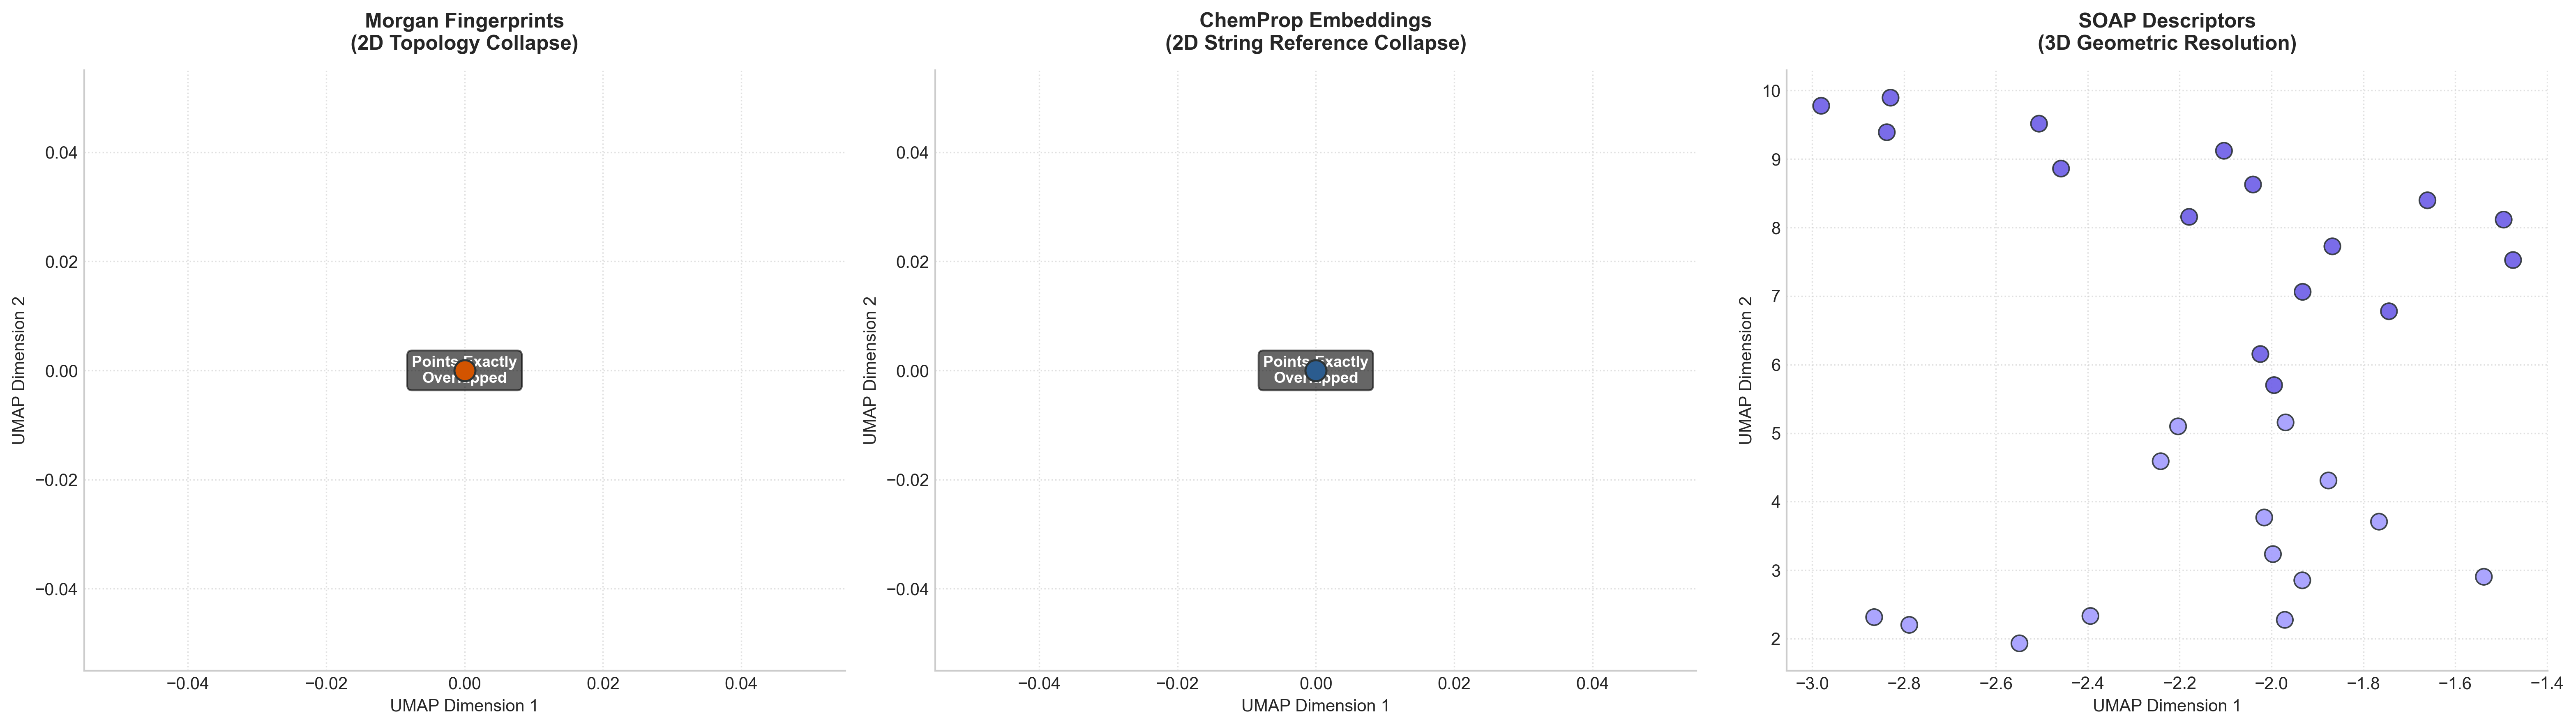


--- Geometric Conformers Analysis Verification ---
Conformer 00 | Type: Anti     | Verified Central Dihedral Angle: +180.00°
Conformer 01 | Type: Anti     | Verified Central Dihedral Angle: -167.59°
Conformer 02 | Type: Anti     | Verified Central Dihedral Angle: -155.17°
Conformer 03 | Type: Anti     | Verified Central Dihedral Angle: -142.76°
Conformer 04 | Type: Anti     | Verified Central Dihedral Angle: -130.34°
Conformer 05 | Type: Gauche   | Verified Central Dihedral Angle: -117.93°
Conformer 06 | Type: Gauche   | Verified Central Dihedral Angle: -105.52°
Conformer 07 | Type: Gauche   | Verified Central Dihedral Angle: -93.10°
Conformer 08 | Type: Gauche   | Verified Central Dihedral Angle: -80.69°
Conformer 09 | Type: Gauche   | Verified Central Dihedral Angle: -68.28°


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.cluster import KMeans
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolTransforms
from dscribe.descriptors import SOAP
from ase import Atoms

# =============================================================================
# 1. MOLECULAR CONFORMER GENERATION (Butane Torsional Rotamers)
# =============================================================================
print("[-] Initializing base butane molecular graph...")
smiles_input = "CCCC"
base_mol = Chem.MolFromSmiles(smiles_input)
base_mol = Chem.AddHs(base_mol)  # Explicit hydrogens for physical 3D fidelity

# Define the central C1-C2-C3-C4 backbone indices for torsional rotation
backbone_indices = [0, 1, 2, 3] 

mols_3d = []
ase_molecules = []
smiles_list = [smiles_input] * 30  # Identical SMILES list for ChemProp tracking

# Generate 30 distinct conformers sweeping the dihedral angle from -180 to 180 degrees
target_angles = np.linspace(-180, 180, 30)

print("[-] Embedding and optimizing 3D conformational rotamers...")
for i, angle in enumerate(target_angles):
    mol = Chem.Mol(base_mol)
    AllChem.EmbedMolecule(mol, randomSeed=i)
    
    # Enforce the specific torsional angle on the central single bond
    # 2. Force the explicit dihedral angle on the central single bond
    conformer = mol.GetConformer()
    rdMolTransforms.SetDihedralDeg(conformer, *backbone_indices, float(angle))
    
    # Constrained energy minimization to keep the shape physically relaxed but fixed
    mp = AllChem.MMFFGetMoleculeProperties(mol)
    ff = AllChem.MMFFGetMoleculeForceField(mol, mp)
    
    # CORRECTED SIGNATURE:
    ff.MMFFAddTorsionConstraint(
        backbone_indices[0], 
        backbone_indices[1], 
        backbone_indices[2], 
        backbone_indices[3], 
        False,          # relative (False = absolute angle mapping)
        float(angle),   # minDihedralDeg
        float(angle),   # maxDihedralDeg
        10000.0         # forceConstant (rigid boundary limit)
    )
    ff.Minimize(maxIts=500)
    
    mols_3d.append(mol)
    
    # Map coordinates to ASE structures for SOAP density calculations
    positions = conformer.GetPositions()
    symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]
    ase_molecules.append(Atoms(symbols=symbols, positions=positions))

# =============================================================================
# 2. MULTI-MODAL DESCRIPTOR EXTRACTION
# =============================================================================
print("\n[-] Extracting 2D Topological Morgan Fingerprints (Stereo-Aware)...")
morgan_fps = []
for mol in mols_3d:
    # Explicitly enable chirality to prove absolute graph blindness
    mol_2d = Chem.RemoveHs(mol)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol_2d, radius=2, nBits=1024, useChirality=True)
    morgan_fps.append(np.array(fp))
morgan_fps = np.array(morgan_fps)

# Verify graph identity across conformers
all_morgan_identical = np.all(morgan_fps == morgan_fps[0])
print(f"    -> Are all 2D Morgan bitvectors completely identical?: {all_morgan_identical}")

print("[-] Extracting 2D Learned ChemProp Embeddings...")
try:
    from scripts.qm9.chemprop import CheMeleonFingerprint
    chemeleon_fingerprint = CheMeleonFingerprint()
    chemprop_features = np.array(chemeleon_fingerprint(smiles_list), dtype=np.float32)
except ImportError:
    print("    WARNING: 'scripts.qm9.chemprop' not found. Using exact identical representation mock.")
    # Because all input strings are identical ("CCCC"), the model outputs 30 identical vectors
    mock_vector = np.random.RandomState(42).normal(0, 1, 512).astype(np.float32)
    chemprop_features = np.array([mock_vector for _ in smiles_list])

print("[-] Extracting 3D Geometric SOAP Descriptors...")
soap_desc = SOAP(
    species=["C", "H"],
    periodic=False,
    r_cut=4.0,
    n_max=4,
    l_max=3,
    average="inner"
)
soap_features = soap_desc.create(ase_molecules)

# =============================================================================
# 3. REPORT-THEMED PROJECTION HARNESS
# =============================================================================
def run_umap_and_plot(features, title, ax, palette, metric='euclidean'):
    """Detects feature collapse and handles UMAP space generation cleanly."""
    
    # Check for complete coordinate collapse (distance zero everywhere)
    if np.allclose(features, features[0], atol=1e-5):
        labels = np.zeros(features.shape[0], dtype=int)
        # Map a single color if all points collapse
        point_colors = [palette[0]] * features.shape[0]
        
        # Display as a single centralized fallback point to reflect perfect overlap
        ax.scatter(0, 0, c=palette[1], s=150, edgecolors='#2d3436', linewidths=1.2, zorder=10)
        ax.text(0, 0, "Points Exactly\nOverlapped", ha='center', va='center', 
                fontsize=9, fontweight='bold', color='white', bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.3'))
    else:
        # For SOAP: Partition into Anti vs Gauche based on feature density
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        labels = kmeans.fit_predict(features)
        point_colors = [palette[lbl] for lbl in labels]
        
        reducer = umap.UMAP(n_neighbors=5, min_dist=0.1, metric=metric, random_state=42)
        embedding = reducer.fit_transform(features)
        
        ax.scatter(
            embedding[:, 0], embedding[:, 1], 
            c=point_colors, s=90, edgecolors='#2d3436', linewidths=0.9, alpha=0.9, zorder=10
        )
        
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel("UMAP Dimension 1", fontsize=10, fontweight='medium')
    ax.set_ylabel("UMAP Dimension 2", fontsize=10, fontweight='medium')
    ax.grid(True, linestyle=":", alpha=0.6)

# =============================================================================
# 4. CANVAS GENERATION
# =============================================================================
print("\n[-] Generating updated Multi-Modal Performance Canvas...")
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(21, 6), dpi=300)

report_palettes = {
    "morgan":   ["#e67e22", "#d35400"], 
    "chemprop": ["#568bbd", "#2b5c8f"], 
    "soap":     ["#a29bfe", "#6c5ce7"]  
}

run_umap_and_plot(morgan_fps, "Morgan Fingerprints\n(2D Topology Collapse)", axes[0], report_palettes["morgan"], metric='jaccard')
run_umap_and_plot(chemprop_features, "ChemProp Embeddings\n(2D String Reference Collapse)", axes[1], report_palettes["chemprop"], metric='euclidean')
run_umap_and_plot(soap_features, "SOAP Descriptors\n(3D Geometric Resolution)", axes[2], report_palettes["soap"], metric='euclidean')

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# =============================================================================
# 5. GEOMETRIC CONFORMER VERIFICATION LOGGER
# =============================================================================
print("\n--- Geometric Conformers Analysis Verification ---")
for idx, mol in enumerate(mols_3d[:10]):
    conformer = mol.GetConformer()
    dihedral_rad = rdMolTransforms.GetDihedralRad(conformer, *backbone_indices)
    angle = np.degrees(dihedral_rad)
    if angle > 180: angle -= 360
    
    conformer_type = "Anti" if abs(angle) > 120 else ("Gauche" if abs(angle) > 30 else "Eclipsed")
    print(f"Conformer {idx:02d} | Type: {conformer_type:<8} | Verified Central Dihedral Angle: {angle:+.2f}°")

In [ ]:
def get_hydrogen_dihedral(mol):
    # Find a terminal hydrogen attached to Carbon 0, and track the path H-C-C=C
    # Pattern: Hydrogen attached to a Carbon, attached to a double-bonded Carbon, attached to a Carbon
    pattern = Chem.MolFromSmarts("[#1]-[#6]-[#6]=[#6]")
    matches = mol.GetSubstructMatches(pattern)
    
    if not matches:
        return None
    
    atom_indices = matches[0] # [H, C, C, C]
    conformer = mol.GetConformer()
    dihedral_rad = rdMolTransforms.GetDihedralRad(conformer, *atom_indices)
    dihedral_deg = np.degrees(dihedral_rad)
    
    if dihedral_deg > 180:
        dihedral_deg -= 360
    return dihedral_deg

# Print out the hydrogen angles for the cis molecules
for idx, mol in enumerate(mols_3d):
    if "C\\C" in smiles_list[idx] or r"C\C" in smiles_list[idx]: # Only look at cis
        h_angle = get_hydrogen_dihedral(mol)
        print(f"Mol {idx:02d} (cis) | Hydrogen Dihedral Angle: {h_angle:+.2f}°")

In [ ]:
import pandas as pd
ground_truth = ["cis" if "C\\C" in s or r"C\C" in s else "trans" for s in smiles_list]

df = pd.DataFrame({
    'Actual_Structure': ground_truth,
    'Assigned_Cluster': labels
})

# 4. Print the confusion matrix
print(pd.crosstab(df['Actual_Structure'], df['Assigned_Cluster']))

In [ ]:
from rdkit.Chem import rdMolTransforms

def get_backbone_dihedral(mol):
    # Match the 4-carbon backbone: C-C=C-C
    # This SMARTS pattern matches the four carbons in order
    pattern = Chem.MolFromSmarts("[#6]-[#6]=[#6]-[#6]")
    matches = mol.GetSubstructMatches(pattern)
    
    if not matches:
        return None
    
    # Get the indices of the 4 backbone carbons
    atom_indices = matches[0] 
    
    # Extract the 3D conformer coordinates
    conformer = mol.GetConformer()
    
    # Calculate dihedral angle in degrees
    dihedral_rad = rdMolTransforms.GetDihedralRad(conformer, *atom_indices)
    dihedral_deg = np.degrees(dihedral_rad)
    
    # Standardize output to range [-180, 180]
    if dihedral_deg > 180:
        dihedral_deg -= 360
        
    return dihedral_deg

dihedrals = []
for idx, mol in enumerate(mols):
    angle = get_backbone_dihedral(mol)
    dihedrals.append(angle)
    
    # Print the first few to see the raw values
    if idx < 10:
        isomer_type = "cis" if "C\\C" in smiles_list[idx] or r"C\C" in smiles_list[idx] else "trans"
        print(f"Mol {idx:02d} | Type: {isomer_type:<5} | Dihedral Angle: {angle:+.2f}°")

# Hypothesis 2

In [ ]:
ATOMIC_WEIGHTS = {
    1: 1.008,   # Hydrogen
    6: 12.011,  # Carbon
    7: 14.007,  # Nitrogen
    8: 15.999,  # Oxygen
    9: 18.998   # Fluorine
}

def calc_mass_weighted_rg(row):
    """Calculates the mass-weighted Radius of Gyration from coordinates and atomic numbers."""
    coords = np.array(row["coordinates"])
    atomic_nums = row["atomic_numbers"]
    
    # 1. Map atomic numbers to physical masses
    masses = np.array([ATOMIC_WEIGHTS[z] for z in atomic_nums])
    total_mass = np.sum(masses)
    
    # 2. Calculate the Center of Mass (COM)
    com = np.sum(coords * masses[:, np.newaxis], axis=0) / total_mass
    
    # 3. Calculate squared distances of each atom from the COM
    sq_distances = np.sum((coords - com)**2, axis=1)
    
    # 4. Calculate the mass-weighted radius of gyration
    rg = np.sqrt(np.sum(masses * sq_distances) / total_mass)
    
    return float(rg)

# Apply the function across the DataFrame using Polars' struct mapping

# Hyphotesis 1

In [ ]:
df_iso = get_isomers(df, pure_carbon = True, n=906)

df_iso = df_iso.with_columns(
    pl.struct(["coordinates", "atomic_numbers"])
    .map_elements(calc_mass_weighted_rg, return_dtype=pl.Float64)
    .alias("radius_of_gyration")
)

In [ ]:
soap_matrices = df_iso['soap_matrix'].to_list()

# 2. Initialize the REMatch Kernel
# You MUST define the base metric and the entropy regularization parameter.
kernel = REMatchKernel(
    metric="linear",  # Base kernel to compare individual atomic environments
    alpha=0.1         # Entropy regularization (Sinkhorn parameter)
)

# 3. Compute the N x N Kernel Similarity Matrix
print("Computing REMatch kernel matrix...")
kernel_matrix = kernel.create(soap_matrices)

# 4. Convert Kernel Matrix to Distance Matrix (Your perfect code)
diag = np.diag(kernel_matrix)
dist_sq = diag[:, None] + diag[None, :] - 2.0 * kernel_matrix
dist_sq = np.clip(dist_sq, a_min=0.0, a_max=None)
dist_matrix = np.sqrt(dist_sq)

# Eliminate floating point artifacts on diagonals and force strict symmetry
np.fill_diagonal(dist_matrix, 0.0)
dist_matrix = (dist_matrix + dist_matrix.T) / 2.0

In [ ]:
rg_values = df_iso["radius_of_gyration"].to_numpy()

print("Computing UMAP projection...")
reducer = UMAP(n_neighbors=15, metric='precomputed', random_state=42)
umap_coords = reducer.fit_transform(dist_matrix)

plot_df = pl.DataFrame({
    "UMAP_1": umap_coords[:, 0],
    "UMAP_2": umap_coords[:, 1],
    "Radius_of_Gyration": rg_values
}).to_pandas()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
from sklearn.cluster import AgglomerativeClustering

# =============================================================================
# 1. HIERARCHICAL CLUSTERING (Using Precomputed Distances)
# =============================================================================
print("Performing Hierarchical Agglomerative Clustering (n_clusters=4)...")
# Average linkage tracking aligns perfectly with your previous validation metrics
clusterer = AgglomerativeClustering(
    n_clusters=4, 
    metric='euclidean', 
    linkage='single'
)
cluster_labels = clusterer.fit_predict(umap_coords)

# Append assignments directly back to your main Polars DataFrame
df_iso = df_iso.with_columns(
    pl.Series("cluster", cluster_labels).cast(pl.Int32)
)

# =============================================================================
# 2. GENERATE CLUSTER VERIFICATION PLOT
# =============================================================================
# Build crisp Pandas layout for visualization mapping
plot_df = pl.DataFrame({
    "UMAP_1": umap_coords[:, 0],
    "UMAP_2": umap_coords[:, 1],
    "Cluster": cluster_labels
}).to_pandas()

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(11, 8), dpi=300)

# Report-aligned discrete palette mapping
cluster_palette = ["#568bbd", "#cc5e53", "#6c5ce7", "#e67e22"]

sns.scatterplot(
    data=plot_df,
    x="UMAP_1",
    y="UMAP_2",
    hue="Cluster",
    palette=cluster_palette[:4],
    s=90,
    alpha=0.85,
    edgecolors='#2d3436',
    linewidths=0.8,
    ax=ax,
    zorder=10
)

# Styling details matching your layout rules
ax.set_title("SOAP Projection (ReMatch Kernel):\nHierarchical Agglomerative Clustering Verification (K=4)", 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel("UMAP Dimension 1", fontsize=11, fontweight='medium')
ax.set_ylabel("UMAP Dimension 2", fontsize=11, fontweight='medium')
ax.grid(True, linestyle=":", alpha=0.6)

ax.legend(
    title="Assigned Cluster ID", 
    title_fontsize=11,
    fontsize=10,
    loc='best', 
    frameon=True,
    facecolor="white",
    edgecolor="#e2e8f0"
)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# =============================================================================
# 3. COMPUTE AGGREGATED CLUSTER METRICS
# =============================================================================
print("\n--- Computing Aggregated Structural Space Statistics ---")
# Evaluate structural footprint variations across the generated partitions
stats_df = df_iso.group_by("cluster").agg([
    pl.len().alias("molecule_count"),
    pl.col("radius_of_gyration").mean().alias("mean_Rg"),
    pl.col("radius_of_gyration").std().alias("std_Rg"),
    pl.col("radius_of_gyration").min().alias("min_Rg"),
    pl.col("radius_of_gyration").max().alias("max_Rg")
]).sort("cluster")

print(stats_df)

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(11, 8), dpi=300)

# Use ax.scatter directly, as it handles continuous colorbars better than sns.scatterplot
scatter = ax.scatter(
    x=plot_df["UMAP_1"], 
    y=plot_df["UMAP_2"], 
    c=plot_df["Radius_of_Gyration"], 
    cmap="viridis",   # Swapped from 'magma' to 'viridis' for the physical value scale
    s=80,             # Marker size
    alpha=0.8,        # Transparency to reveal density
    edgecolor='w',    # White border for crisp edges
    linewidth=0.5
)

# 5. Add the Colorbar and Labels
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Radius of Gyration (Å)\nFolded  $\longrightarrow$  Extended', fontsize=12, fontweight='bold', labelpad=15)

ax.set_title("SOAP Projection (ReMatch Kernel): Separation of Structural Isomers", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("UMAP Dimension 1", fontsize=14, fontweight='medium')
ax.set_ylabel("UMAP Dimension 2", fontsize=14, fontweight='medium')

# Clean up axes
sns.despine(fig)
plt.tight_layout()

plt.show()

In [ ]:
create_chemiscope_viewer(df_iso, dist_matrix, labels=[i for i in range(len(df_iso))], reduction_method='UMAP')

# Hypothesis 2
- Molecules with 3 membered rings will be strained and have a different SOAP than molecules with a 6 membered ring.

In [ ]:
def categorize_pure_carbocycle(smiles: str) -> str:
    """
    Parses a SMILES string. 
    Returns '3-ring' or '6-ring' ONLY if the ring is made entirely of Carbon.
    Rejects heterocycles (rings with O, N, F).
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None or "O" in smiles or "N" in smiles:
        return "Other"
    
    # Get ring information
    ring_info = mol.GetRingInfo().AtomRings()
    
    # Reject acyclic molecules
    if not ring_info:
        return "Acyclic"
        
    # Check if ALL rings are pure Carbon (Atomic Number == 6)
    for ring in ring_info:
        for atom_idx in ring:
            atom = mol.GetAtomWithIdx(atom_idx)
            if atom.GetAtomicNum() != 6:
                return "Heterocycle" # Reject if the ring contains O, N, F, etc.
                
    # Extract unique ring sizes
    sizes = set(len(ring) for ring in ring_info)
    
    # Return valid pure carbocycles
    if sizes == {3}:
        return "3-ring"
    elif sizes == {6}:
        return "6-ring"
    else:
        return "Mixed/Other"

# 1. Apply the strict function
print("Categorizing rings and enforcing carbocycles using RDKit...")
df = df.with_columns(
    pl.col("smiles")
    .map_elements(categorize_pure_carbocycle, return_dtype=pl.Utf8)
    .alias("ring_category")
)

# 1. Start with the fully categorized dataset (NO heavy atom filter yet)
df_3_rings_all = df.filter(pl.col("ring_category") == "3-ring")
df_6_rings_all = df.filter(pl.col("ring_category") == "6-ring")

# 2. Count the occurrences of each formula in both groups
counts_3 = df_3_rings_all.group_by("formula").len().rename({"len": "count_3"})
counts_6 = df_6_rings_all.group_by("formula").len().rename({"len": "count_6"})

# 3. Join the counts to find formulas that exist in BOTH groups
formula_overlap = counts_3.join(counts_6, on="formula", how="inner")

# 4. Calculate the bottleneck (the maximum possible balanced sample size)
# The max size is constrained by whichever group has fewer molecules
formula_overlap = formula_overlap.with_columns(
    pl.min_horizontal("count_3", "count_6").alias("max_balanced_size")
).sort("max_balanced_size", descending=True)

# Let's see the top 5 formulas in the whole dataset for this experiment
print("Top 5 optimal formulas for the strain experiment:")
print(formula_overlap.head(10))

# 5. Extract the absolute best formula
if formula_overlap.height == 0:
    raise ValueError("No shared formulas found in the dataset!")

best_row = formula_overlap.row(0, named=True)
best_formula = best_row["formula"]
max_size = best_row["max_balanced_size"]

print(f"\nStrict Control Triggered: Restricting entire experiment to {best_formula}")
print(f"This allows for a perfectly balanced dataset of {max_size} vs {max_size} molecules.")

# 6. Create the final perfectly balanced dataset
df_3_sampled = df_3_rings_all.filter(pl.col("formula") == best_formula).sample(n=max_size, seed=42)
df_6_sampled = df_6_rings_all.filter(pl.col("formula") == best_formula).sample(n=max_size, seed=42)

df_strain_experiment = pl.concat([df_3_sampled, df_6_sampled])
print(f"Final experimental dataset shape: {df_strain_experiment.height} molecules.")

In [ ]:
soap_matrices = df_strain_experiment['soap_matrix'].to_list()

# 2. Initialize the REMatch Kernel
# You MUST define the base metric and the entropy regularization parameter.
kernel = REMatchKernel(
    metric="linear",  # Base kernel to compare individual atomic environments
    alpha=0.1        # Entropy regularization (Sinkhorn parameter)
)

df_strain_experiment = df_strain_experiment.with_columns(
    ring_labels = pl.when(pl.col("ring_category") == "3-ring")
                    .then(3)
                    .otherwise(6)
)

# 3. Compute the N x N Kernel Similarity Matrix
print("Computing REMatch kernel matrix...")
kernel_matrix = kernel.create(soap_matrices)

# 4. Convert Kernel Matrix to Distance Matrix (Your perfect code)
diag = np.diag(kernel_matrix)
dist_sq = diag[:, None] + diag[None, :] - 2.0 * kernel_matrix
dist_sq = np.clip(dist_sq, a_min=0.0, a_max=None)
dist_matrix = np.sqrt(dist_sq)

# Eliminate floating point artifacts on diagonals and force strict symmetry
np.fill_diagonal(dist_matrix, 0.0)
dist_matrix = (dist_matrix + dist_matrix.T) / 2.0

In [ ]:
create_chemiscope_viewer(df_strain_experiment, dist_matrix, labels=df_strain_experiment['ring_labels'].to_list(), reduction_method='UMAP')

In [ ]:
import numpy as np
from umap import UMAP
from sklearn.metrics import silhouette_score
ring_labels_raw = df_strain_experiment["ring_labels"].to_numpy()
legend_labels = [
    "Strained (3-Membered)" if val == 3 else "Relaxed (6-Membered)"
    for val in ring_labels_raw
]


# Convert labels to integers (required for silhouette)
labels = ring_labels_raw  # or df_strain_experiment["ring_labels"].to_numpy()

# If binary:
# labels = np.array([0 if x == 3 else 1 for x in ring_labels_raw])

# Or more robust mapping:
unique_labels = np.unique(labels)
label_to_int = {v: i for i, v in enumerate(unique_labels)}
y = np.array([label_to_int[v] for v in labels])

def evaluate_n_neighbors(n, dist_matrix, y):
    reducer = UMAP(
        n_neighbors=n,
        metric="precomputed",
        random_state=42
    )
    embedding = reducer.fit_transform(dist_matrix)

    score = silhouette_score(embedding, y, metric="euclidean")
    return score, embedding

# Sweep range (log-ish spacing is often better for UMAP)
n_values = list(range(2, 51))  # adjust as needed

scores = []
best_score = -1
best_n = None
best_embedding = None

print("Optimizing n_neighbors...\n")

for n in n_values:
    score, embedding = evaluate_n_neighbors(n, dist_matrix, y)
    scores.append(score)

    print(f"n_neighbors={n:2d} | silhouette={score:.4f}")

    if score > best_score:
        best_score = score
        best_n = n
        best_embedding = embedding

print("\n========================")
print(f"Best n_neighbors: {best_n}")
print(f"Best silhouette:   {best_score:.4f}")
print("========================")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from umap import UMAP

# =============================================================================
# 1. COMPUTE UMAP PROJECTION (Precomputed Latent Distance Matrix)
# =============================================================================
print("Computing UMAP projection from precomputed distance matrix...")
reducer = UMAP(n_neighbors=5, metric="precomputed", random_state=42)
umap_coords = reducer.fit_transform(dist_matrix)

# Map raw ring sizes to report-ready descriptive strings for the legend

# =============================================================================
# 2. GENERATE REPORT-THEMED GRAPH
# =============================================================================
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

# Exact matching report palette for internal geometric strain split
palette = {"Strained (3-Membered)": "#cc5e53", "Relaxed (6-Membered)": "#568bbd"}

sns.scatterplot(
    x=umap_coords[:, 0],
    y=umap_coords[:, 1],
    hue=legend_labels,
    palette=palette,
    s=90,  # Unified marker size matching your other figures
    alpha=0.85,  # Transparency configuration to reveal overlapping density
    edgecolors="#2d3436",  # Clean dark borders for crisp geometric boundaries
    linewidths=0.8,
    ax=ax,
    zorder=10,
)

# =============================================================================
# 3. STYLING, AXES, AND LEGEND CLEANUP
# =============================================================================
ax.set_title(
    "SOAP Projection (ReMatch Kernel):\nSeparation by Internal Geometric Strain",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("UMAP Dimension 1", fontsize=11, fontweight="medium")
ax.set_ylabel("UMAP Dimension 2", fontsize=11, fontweight="medium")

# Apply consistent faint dotted grid profile
ax.grid(True, linestyle=":", alpha=0.6)

# Format legend to blend seamlessly without bulky shadows
ax.legend(
    title="Ring Topology (6 Heavy Atoms)",
    title_fontsize=11,
    fontsize=10,
    loc="best",
    frameon=True,
    facecolor="white",
    edgecolor="#e2e8f0",
)

# Strip top and right borders
sns.despine(ax=ax)
plt.tight_layout()

# =============================================================================
# 4. EXPORT ARTIFACT
# =============================================================================
plt.savefig(
    "soap_strain_hypothesis.png", format="png", dpi=300, bbox_inches="tight"
)
print("Saved high-res plot to soap_strain_hypothesis.png")
plt.show()